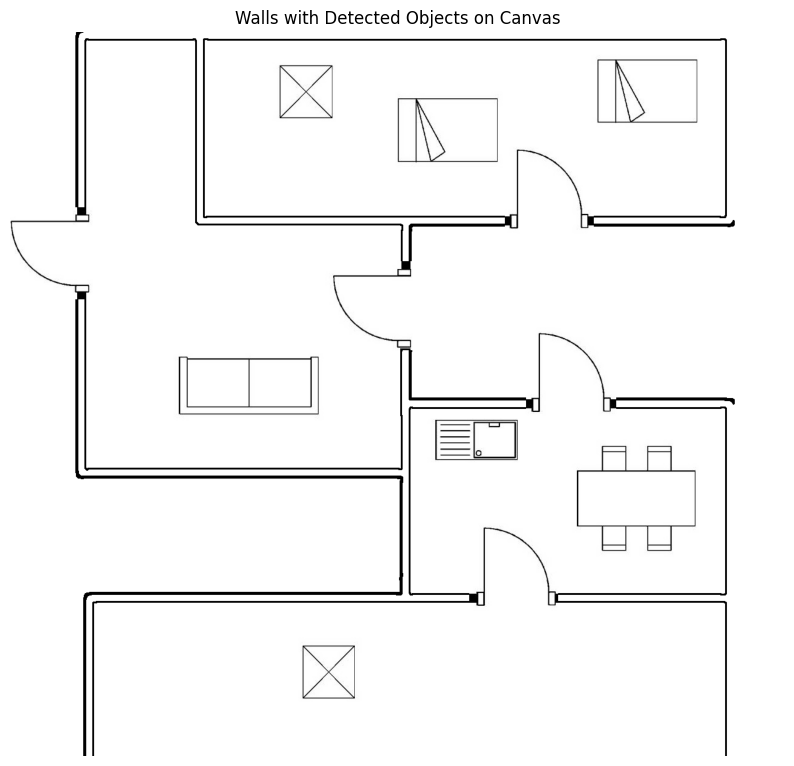

In [14]:
import cv2
import numpy as np
import json
import pandas as pd
from matplotlib import pyplot as plt
import os

# Define the dimensions of the blank canvas (Adjust as needed)
canvas_width = 1281  # Image width
canvas_height = 1197  # Image height
background_color = (255)  # White background for grayscale

# Create a blank canvas
canvas = np.ones((canvas_height, canvas_width), dtype=np.uint8) * background_color

# Load coordinates of walls
with open('wall_coordinates.json', 'r') as file:
    wall_coordinates = json.load(file)

# Draw walls on the blank canvas
for contour_points in wall_coordinates:
    contour_array = np.array(contour_points, dtype=np.int32)
    contour_array = contour_array.reshape((-1, 1, 2))  # Required shape for drawContours
    cv2.drawContours(canvas, [contour_array], -1, (0, 0, 0), thickness=2)  # Draw walls in black

# Load the object coordinates from the CSV file
csv_path = 'cropped_images/coordinates.csv'  # Update this path
object_data = pd.read_csv(csv_path)

# Superimpose detected objects onto the canvas
cropped_images_dir = 'cropped_images'  # Update this path

for index, row in object_data.iterrows():
    # Get the x and y coordinates of the detected objects
    x, y = row['x'], row['y']
    
    # Get the filename of the cropped image from the CSV
    img_filename = row['filename']
    img_path = os.path.join(cropped_images_dir, img_filename)
    
    # Load the cropped image
    cropped_img = cv2.imread(img_path)
    
    # Ensure the image is within the canvas bounds
    img_height, img_width = cropped_img.shape[:2]
    if y + img_height <= canvas_height and x + img_width <= canvas_width:
        canvas[y:y+img_height, x:x+img_width] = cropped_img[:, :, 0]  # Overlay cropped image onto canvas

# Convert canvas to RGB for visualization if needed
canvas_rgb = cv2.cvtColor(canvas, cv2.COLOR_GRAY2RGB)

# Display the resulting image with walls and objects
plt.figure(figsize=(10, 10))
plt.imshow(canvas_rgb)
plt.title('Walls with Detected Objects on Canvas')
plt.axis('off')  # Hide axis
plt.show()
